In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/ML Supervised Algorithms/3. ML Decision Trees-1/SteelPlant.csv')

In [4]:
df.head()

,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,0,584,590,909972,909977,16,8,5,2274,113,...,-0.5000,-0.0104,0.1417,0,0,0,1,0,0,0
1,1,808,816,728350,728372,433,20,54,44478,70,...,0.7419,-0.2997,0.9491,0,0,0,0,0,0,1
2,2,39,192,2212076,2212144,11388,705,420,1311391,29,...,-0.0105,-0.0944,1.0000,0,0,1,0,0,0,0
3,3,781,789,3353146,3353173,210,16,29,3202,114,...,0.6667,-0.0402,0.4025,0,0,1,0,0,0,0
4,4,1540,1560,618457,618502,521,72,67,48231,82,...,0.9158,-0.2455,0.9998,0,0,0,0,0,0,1


In [5]:
df.columns

Index(['id', 'X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum',
       'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')

In [6]:
df.dtypes

id                         int64
X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Minimum_of_Luminosity      int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300           int64
TypeOfSteel_A400           int64
Steel_Plate_Thickness      int64
Edges_Index              float64
Empty_Index              float64
Square_Index             float64
Outside_X_Index          float64
Edges_X_Index            float64
Edges_Y_Index            float64
Outside_Global_Index     float64
LogOfAreas               float64
Log_X_Index              float64
Log_Y_Index              float64
Orientation_Index        float64
Luminosity_Index         float64
SigmoidOfAreas           float64
Pastry                     int64
Z_Scratch                  int64
K_Scatch  

# Root Entropy for Decision Tree

In [7]:
fault_types = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

df['Target'] = df[fault_types].idxmax(axis = 1)

def entropy_calc(y):
    probabilities = y.value_counts(normalize = True).to_numpy()
    entropies = - probabilities * np.log2(probabilities)
    return round(np.sum(entropies), 2)

root_entropy = entropy_calc(df['Target'])
print(f"The root entropy is: {root_entropy}")

The root entropy is: 2.36


# Assessing Dataset Balance for Decision Tree Implementation

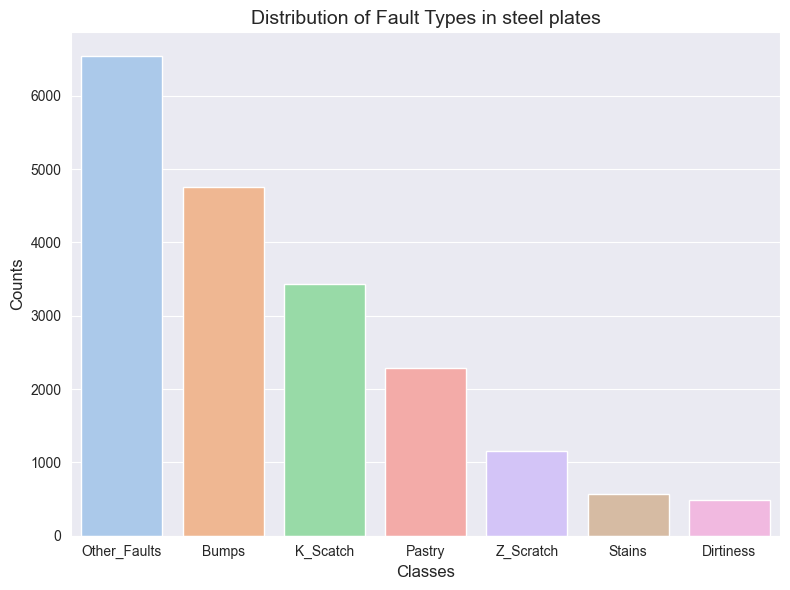

In [8]:
fault_types = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

df['Target'] = df[fault_types].idxmax(axis = 1)

fault_counts = df['Target'].value_counts()

custom_palette = sns.color_palette('pastel')

plt.figure(figsize = (8,6))

sns.barplot(x= fault_counts.index, y = fault_counts.to_numpy(), palette = custom_palette)

plt.xlabel("Classes", fontsize = 12)
plt.ylabel("Counts", fontsize = 12)
plt.title("Distribution of Fault Types in steel plates", fontsize = 14)

plt.tight_layout()
plt.show()

# Find Root Node

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

x = df[['Pixels_Areas', 'SigmoidOfAreas']]
y = df['Target']

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42)

dt_classifier = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dt_classifier.fit(x_train, y_train)

root_node_feature_index = dt_classifier.tree_.feature[0]
root_node_feature_name = x.columns[root_node_feature_index]
root_node_gini_value = dt_classifier.tree_.impurity[0]

print(f"The root node feature is: {root_node_feature_name}")
print(f"The Gini value of the root node is: {root_node_gini_value:.2f}")

The root node feature is: Pixels_Areas
The Gini value of the root node is: 0.77


# DT - Root Split

In [10]:
x = df[['Pixels_Areas', 'SigmoidOfAreas']]
y = df['Target']

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

x_train1, _, y_train1, _ = train_test_split(x, y, random_state = 42)
tree1 = DecisionTreeClassifier(max_depth = 3, random_state = 42)
tree1.fit(x_train1, y_train1)
root_feature_1 = x.columns[tree1.tree_.feature[0]]
root_gini_1 = tree1.tree_.impurity[0]

x_train2 = x_train1.drop(x_train1.index[0])
y_train2 = y_train1.drop(y_train1.index[0])
tree2 = DecisionTreeClassifier(max_depth = 3, random_state = 42)
tree2.fit(x_train2, y_train2)
root_feature_2 = x.columns[tree2.tree_.feature[0]]
root_gini_2 = tree2.tree_.impurity[0]

print(f"Original Root: {root_feature_1}, Gini: {root_gini_1}")
print(f"Final Root: {root_feature_2}, Gini: {root_gini_2}")

Original Root: Pixels_Areas, Gini: 0.7727751234871035
Final Root: Pixels_Areas, Gini: 0.7727904641619855


In [11]:
X = df[['Pixels_Areas', 'SigmoidOfAreas']]
y = df['Target']

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Original Tree
X_train1, _, y_train1, _ = train_test_split(X, y, random_state=42)
tree1 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree1.fit(X_train1, y_train1)
root_feature_1 = X.columns[tree1.tree_.feature[0]]
root_gini_1 = tree1.tree_.impurity[0]

# Remove 1 row from training set and retrain
X_train2 = X_train1.drop(X_train1.index[0])
y_train2 = y_train1.drop(y_train1.index[0])
tree2 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree2.fit(X_train2, y_train2)
root_feature_2 = X.columns[tree2.tree_.feature[0]]
root_gini_2 = tree2.tree_.impurity[0]

# Compare
print(f"Original Root: {root_feature_1}, Gini: {root_gini_1:.4f}")
print(f"After Removal: {root_feature_2}, Gini: {root_gini_2:.4f}")

Original Root: Pixels_Areas, Gini: 0.7728
After Removal: Pixels_Areas, Gini: 0.7728


# Most Misclassified DT

In [12]:
df.columns

Index(['id', 'X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum',
       'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults', 'Target'],
      dtype='object')

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

x = df.drop(columns = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults', 'Target'], axis = 1)
y = df['Target']

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42)

dt_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42, class_weight = 'balanced')

dt_classifier.fit(x_train, y_train)

y_pred = dt_classifier.predict(x_test)

report = classification_report(y_test, y_pred, target_names = np.unique(y_train))
print(report)

              precision    recall  f1-score   support

       Bumps       0.39      0.40      0.40      1165
   Dirtiness       0.13      0.18      0.15       107
    K_Scatch       0.84      0.84      0.84       852
Other_Faults       0.40      0.40      0.40      1671
      Pastry       0.22      0.20      0.21       605
      Stains       0.63      0.65      0.64       130
   Z_Scratch       0.41      0.44      0.43       275

    accuracy                           0.46      4805
   macro avg       0.43      0.44      0.44      4805
weighted avg       0.46      0.46      0.46      4805



# Optimizing Decision Tree Depth

In [14]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, KFold, cross_validate

depths = [3, 5, 7, 11, 13, 15, 19, 20]

kfold = KFold(n_splits = 10, shuffle = True, random_state = 42)

best_depth = None
best_val_score = 0

for depth in depths:
    tree_clf = DecisionTreeClassifier(max_depth = depth, random_state = 42, class_weight = 'balanced')
    cv_acc_results = cross_validate(tree_clf, x_train, y_train, cv = kfold, scoring = 'accuracy', return_train_score = True)
    avg_val_score = cv_acc_results['test_score'].mean()
    if avg_val_score > best_val_score:
        best_val_score = avg_val_score
        best_depth = depth
    print(f"K-Fold for depth: {depth} - Accuracy Mean: Train: {cv_acc_results['train_score'].mean() * 100:.2f}%, Validation: {cv_acc_results['test_score'].mean() * 100:.2f}%")
    print(f"K-Fold for depth: {depth} - Accuracy Std: Train: {cv_acc_results['train_score'].std() * 100:.2f}%, Validation: {cv_acc_results['test_score'].std() * 100:.2f}%")
    print('***************')

K-Fold for depth: 3 - Accuracy Mean: Train: 42.29%, Validation: 42.19%
K-Fold for depth: 3 - Accuracy Std: Train: 0.32%, Validation: 1.25%
***************
K-Fold for depth: 5 - Accuracy Mean: Train: 50.11%, Validation: 49.67%
K-Fold for depth: 5 - Accuracy Std: Train: 1.49%, Validation: 1.45%
***************
K-Fold for depth: 7 - Accuracy Mean: Train: 46.71%, Validation: 44.67%
K-Fold for depth: 7 - Accuracy Std: Train: 0.83%, Validation: 1.40%
***************
K-Fold for depth: 11 - Accuracy Mean: Train: 57.57%, Validation: 46.65%
K-Fold for depth: 11 - Accuracy Std: Train: 0.65%, Validation: 0.99%
***************
K-Fold for depth: 13 - Accuracy Mean: Train: 65.73%, Validation: 48.22%
K-Fold for depth: 13 - Accuracy Std: Train: 0.42%, Validation: 1.43%
***************
K-Fold for depth: 15 - Accuracy Mean: Train: 74.60%, Validation: 48.02%
K-Fold for depth: 15 - Accuracy Std: Train: 0.77%, Validation: 1.16%
***************
K-Fold for depth: 19 - Accuracy Mean: Train: 88.19%, Validation:

In [15]:
best_tree_clf = DecisionTreeClassifier(max_depth = 5, random_state = 42, class_weight = 'balanced')
best_tree_clf.fit(x_train, y_train)
print(f"The model accuracy on testing data with best depth is {best_tree_clf.score(x_test, y_test):.2f}%")

The model accuracy on testing data with best depth is 0.50%


# DT - Feature Importance

Top 3 Features:
1. Outside_X_Index with an importance of 0.3198
2. Pixels_Areas with an importance of 0.2949
3. Length_of_Conveyer with an importance of 0.1254


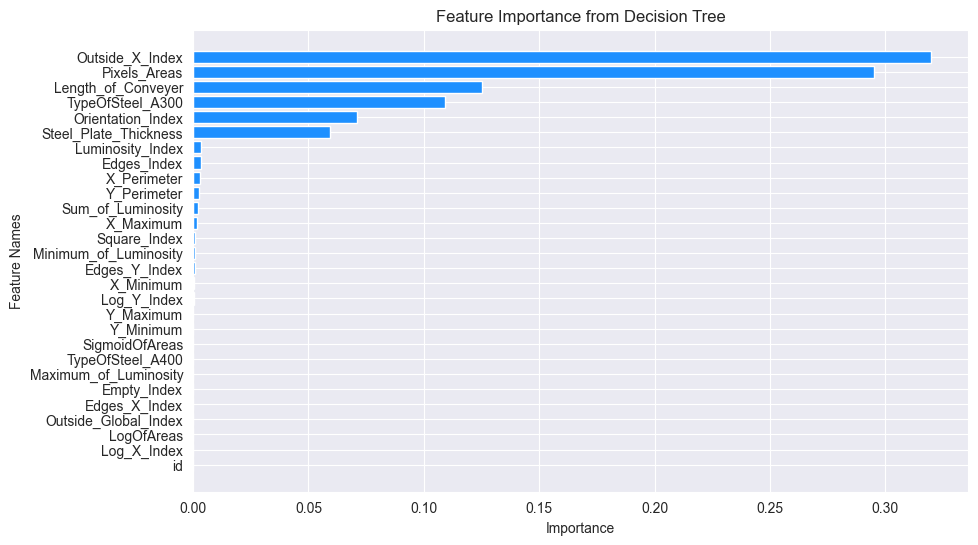

In [16]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = x_train.columns

feature_importances = best_tree_clf.feature_importances_

sorted_idx = np.argsort(feature_importances)[::-1]

print("Top 3 Features:")
for i in range(3):
    feature_index = sorted_idx[i]
    print(f"{i + 1}. {feature_names[feature_index]} with an importance of {feature_importances[feature_index]:.4f}")

sorted_feature_names = [feature_names[i] for i in sorted_idx]
sorted_importances = feature_importances[sorted_idx]

plt.figure(figsize=(10,6))
plt.barh(range(len(sorted_importances)), sorted_importances, align = 'center', color = 'dodgerblue')
plt.yticks(range(len(sorted_importances)), sorted_feature_names)
plt.xlabel('Importance')
plt.ylabel('Feature Names')
plt.title('Feature Importance from Decision Tree')
plt.gca().invert_yaxis()
plt.show()

# SMOTE Imbalance

In [17]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("\nBefore SMOTE:")
print(Counter(y))

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

print("\nAfter SMOTE:")
print(Counter(y_resampled))


Before SMOTE:
Counter({'Other_Faults': 6540, 'Bumps': 4761, 'K_Scatch': 3431, 'Pastry': 2284, 'Z_Scratch': 1150, 'Stains': 568, 'Dirtiness': 485})

After SMOTE:
Counter({'Stains': 6540, 'Other_Faults': 6540, 'K_Scatch': 6540, 'Bumps': 6540, 'Pastry': 6540, 'Z_Scratch': 6540, 'Dirtiness': 6540})


# Comparing OOB Scores

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Step 1: Split the original data into training and testing sets
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.33, random_state=42)

# Step 2: Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_orig, y_train_orig)

# Step 3: Split the resampled data (you may skip this if already split above)
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_resampled, y_resampled, test_size=0.33, random_state=42)

# Step 4: Initialize Random Forest for original data
rf_classifier_orig = RandomForestClassifier(oob_score=True, random_state=42)

# Step 5: Train the classifier on the original data
rf_classifier_orig.fit(X_train_orig, y_train_orig)

# Step 6: Get OOB score for original data
oob_score_orig = rf_classifier_orig.oob_score_
print(f"The OOB score for original data is: {oob_score_orig:.4f}")

# Step 7: Initialize Random Forest for resampled data
rf_classifier_res = RandomForestClassifier(oob_score=True, random_state=42)

# Step 8: Train the classifier on the resampled (SMOTE) data
rf_classifier_res.fit(X_train_res, y_train_res)

# Step 9: Get OOB score for resampled data
oob_score_res = rf_classifier_res.oob_score_
print(f"The OOB score for resampled data is: {oob_score_res:.4f}")

The OOB score for original data is: 0.4246
The OOB score for resampled data is: 0.5388


# Most Accurate Class

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Predict the classes for the test set using the SMOTE-trained model
y_pred = rf_classifier_res.predict(X_test_res)

# Step 2: Generate the classification report as a dictionary
class_report = classification_report(y_test_res, y_pred, output_dict=True)

# Step 3: Print the human-readable version of the classification report
print("Classification Report:\n")
print(classification_report(y_test_res, y_pred))

# Step 4: Print the confusion matrix (optional, for verification)
print("Confusion Matrix:\n")
print(confusion_matrix(y_test_res, y_pred))

# Step 5: Filter out only actual class labels (exclude summary stats)
excluded_keys = ['accuracy', 'macro avg', 'weighted avg']
true_classes = [label for label in class_report.keys() if label not in excluded_keys]

# Step 6: Find the class with the highest recall
most_correctly_classified = max(
    true_classes,
    key=lambda x: class_report[x]['recall']
)
most_correctly_classified_score = class_report[most_correctly_classified]['recall']

# Step 7: Print the result
print(f"\n✅ The most correctly classified class is: {most_correctly_classified} with a recall of: {most_correctly_classified_score:.4f}")

Classification Report:

              precision    recall  f1-score   support

       Bumps       0.34      0.35      0.34      1416
   Dirtiness       0.59      0.60      0.59      1433
    K_Scatch       0.81      0.86      0.84      1385
Other_Faults       0.30      0.28      0.29      1466
      Pastry       0.37      0.37      0.37      1402
      Stains       0.86      0.86      0.86      1452
   Z_Scratch       0.47      0.44      0.45      1430

    accuracy                           0.54      9984
   macro avg       0.53      0.54      0.54      9984
weighted avg       0.53      0.54      0.54      9984

Confusion Matrix:

[[ 494  114   32  380  192   31  173]
 [ 106  863   19  104  168   32  141]
 [  48   12 1195   51   43    6   30]
 [ 377  135  115  413  205   52  169]
 [ 210  172   59  212  518   46  185]
 [  51   33    5   42   46 1250   25]
 [ 171  146   51  176  218   34  634]]

✅ The most correctly classified class is: K_Scatch with a recall of: 0.8628


# Optimizing Random Forest

In [20]:
from sklearn.model_selection import RandomizedSearchCV

# Define a more extensive parameter grid for Random Search
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Initialize the RandomForest classifier
rf = RandomForestClassifier(random_state=42)

# TODO: Setup RandomizedSearchCV with randomforest model,  30 iterations and 2-fold cross-validation
random_search = RandomizedSearchCV(estimator=rf, param_distributions=params, n_iter=30, cv=2, verbose=1, random_state=42)

# TODO: Perform the Random Search
random_search.fit(X_train_res, y_train_res)

# Print the best parameters and the best score
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation score achieved: ", random_search.best_score_)

Fitting 2 folds for each of 30 candidates, totalling 60 fits
Best parameters found:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
Best cross-validation score achieved:  0.5278243709916133


# RF for Feature Importance

The most important feature is: SigmoidOfAreas with an importance score of: 0.5019


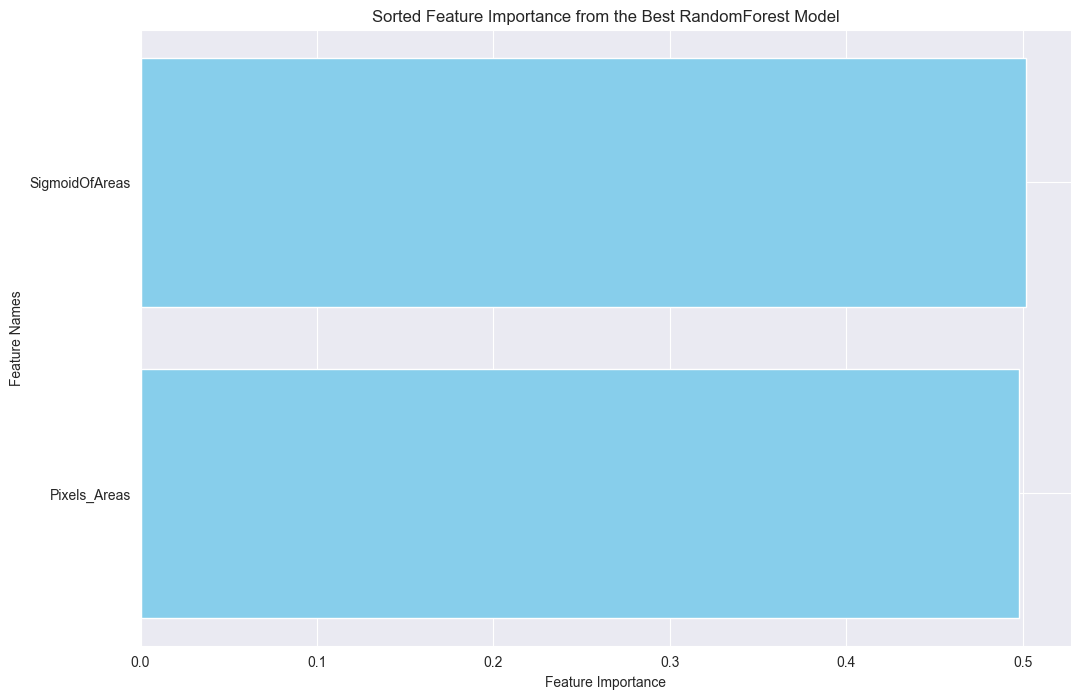

In [23]:
# TODO: Get the best RandomForest model from RandomizedSearchCV
best_rf_model = random_search.best_estimator_

# TODO: Get feature importances from the best model
feature_importances = best_rf_model.feature_importances_

# Get feature names
feature_names = X_train_res.columns  # Adjust this if your feature names are stored differently

# TODO: Sort the features by their importance (and keep track of their names)
sorted_indices = np.argsort(feature_importances)[::-1] # Hint sort only the `indicies` of the feature according to their importances.
sorted_importances = feature_importances[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Print the most important feature and its importance score
most_important_feature_name = sorted_feature_names[0]
print(f"The most important feature is: {most_important_feature_name} with an importance score of: {sorted_importances[0]:.4f}")

# TODO: Plot all feature importances sorted
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center', color='skyblue')
plt.yticks(range(len(sorted_importances)), sorted_feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Feature Names')
plt.title('Sorted Feature Importance from the Best RandomForest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance on top
plt.show()